In [1]:
# GPU support

# This library can use CuPy for GPU acceleration.
# We recommend installing CuPy via conda-forge:
# conda install -c conda-forge cupy cuda-version=12.4


The following example shows an optimization problem, where we place 16 cubic magnets around a ring, and we would like to determine their optimal orientations, such that the magnetic field homogeneity in Bx is optimized. It is important to note, that the field can only be optimized for the set of measurement points, where we estimate the field, here called the sensor points. Using the function sensorring, the psoitions of a ring of sensors can be generated. 



Import libraries

In [2]:
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
from magoptlib.genetic_algorithm import genetic_algorithm_gpu
from magoptlib.sh_fitting import precompute_sh_coeffs, get_m_l_vals
from magoptlib.sh_gpu import get_orientations_gpu
from magoptlib.synthetic_measurement import simulate_magnetic_measurement
from magoptlib.pos import magnetring_gpu, sensorring

Generate synthetic measurement data

The library was created to optimize the orientations of real magnets. However, it also offers the possibility to generate synthetic measurement datasets. This is possible via the Magpylib Python library.

The sampling is done using the Fibonacci lattice method, which offers an even distribution on the sphere. 

In [3]:
n_theta = 18 # Number of theta for the Fibonacci lattice sampling
n_phi   = 36 # Number of phi for the Fibonacci lattice sampling
radius = 20.0 # Radius of the measurement sphere
n_magnets = 16 # Number of magnets in the Halbach ring

measurements = [
    simulate_magnetic_measurement(n_theta, n_phi, radius)
    for _ in range(n_magnets)
]

Bx = np.stack([m[0] for m in measurements], axis=0)  # (16, 648)
By = np.stack([m[1] for m in measurements], axis=0)  # (16, 648)
Bz = np.stack([m[2] for m in measurements], axis=0)  # (16, 648)

# DO NOT stack these:
theta_values = measurements[0][3]   # (648,)
phi_values   = measurements[0][4]   # (648,)

assert Bx.shape == By.shape == Bz.shape == (n_magnets, n_theta * n_phi)

Initialization

Since the optimization is done by using the SH coefficients, we first have to map the magnetic field data to spherical harmonics. We first have to initialize the maximum order of the approximation, and therefore get the degree and order of the spherical harmoincs. 

- $l (l=0, 1, 2, ...)$: is the degree, which determines the complexity of the function in terms of the number of nodal lines
- $m (m=-l,...,+l)$ is the order, specifies the azimuthal variation within a given degree

In [4]:
# ============================================================
# Initialization
# ============================================================

max_sh_order = 24 # Maximum spherical harmonic order for the fitting

# Get the (l,m) values for the spherical harmonics
m_values, l_values = get_m_l_vals(max_sh_order)

In this example, the initial orientations are given by the theoretical Halbach configuration. 

<p align="center"><img src="halbach_orient.png" style="width:15%;" alt="image">


In [5]:
# Initial angles for the magnets
init_angles = cp.linspace(0, 4*np.pi, n_magnets, endpoint=False, dtype=np.float64)

In [6]:
# based on the number of magnets and their initial angles, get their positions and orientations
positions_cpu, init_orientations_gpu = magnetring_gpu(n_magnets, init_angles, radius = 40)

# Generate the sensor positions on a ring where we want to optimize the field
points_of_interest = sensorring(24, radius=20)

# Map the magnetic field measurement data to spherical harmonics and compute the SH coefficients
sh_coeff_X, sh_coeff_Y, sh_coeff_Z = precompute_sh_coeffs(Bx, By, Bz, theta_values, phi_values, n_magnets, radius, max_sh_order)

# Convert the positions, and the SH coefficients to cp arrays
positions_gpu = cp.asarray(positions_cpu)           # (8,3)
shX_gpu = cp.asarray(sh_coeff_X, dtype=cp.float64)
shY_gpu = cp.asarray(sh_coeff_Y, dtype=cp.float64)
shZ_gpu = cp.asarray(sh_coeff_Z, dtype=cp.float64)

## Genetic Algorithms


In this library, a traditional genetic algorithm, and the ACROMUSE algorithm is implemented. 

Genetic algorithms (GA) are inspired by natural genetics. It is a heuristic and stochastic method, particularly useful for solving complex and nonlinear optimization problems. It does not require any prior knowledge, as they find the solution by minimizing or maximizing an objective, called fitness function. This function measures how well each potential solution solves the target problem. 

For the genetic algorithm, three different parent selections are available. 
The 'best_50_selection' sorts the population by their fitness values and keeps the top 50%, from which individuals for crossover and mutation are sampled with uniform probability. 
The 'roulette_wheel_selection' sets the probability to be chosen depending the individual's fitness value. 
The 'tournament_selection' randomly draws k individuals from the population and chooses the one with the best fitness to be a parent. Changing k alters the probabilities, with a small k favoring worse members, which helps to introduce randomness. 

The ACROMUSE algorithm uses an adaptive tournament selection, which changes the size of k depending on standard deviation, to keep a balance in solution space diversity.



First, the set of possible angles has to be given that the algorithm can choose from. Naturally, the more possible angles to choose from, the more possible combinations, which we have to take into account when setting the max number of iterations. 

In [ ]:
# Give the possible angles the algorithm can choose from
possible_angles_cpu = np.linspace(-15*np.pi/180, 15*np.pi/180, 3, dtype=np.float64)
possible_angles_gpu = cp.asarray(possible_angles_cpu, dtype=cp.float64)  # Convert to cp array

Before starting the algorithm, a few parameters have to be set. The population size sets the number of individuals in a generation, i.e. sets the number of potential solutions examined in one iteration. Choosing a too big number could result in performance issues in parallel execution, depending on the specific GPU memory.

Setting the num_gens sets the maximum number of iterations. More iterations will result in a longer runtime, but the probability of finding the best optimal configuration is also higher.

The mut_rate sets the probability of mutations of the parents for genetic algorithms, it introduces randomness thus helps to avoid premature convergence. The mut_rate is not used for ACROMUSE, since it uses adaptive mutation rates. 

Since GA is a heuristic algorithm, finding the global optimum is not guaranteed. Therefore, 

Best fitness: 0.07847769983579798
sum of Bx: 2602.5058533711394
sum of By: 526.0330064613588
sum of Bz: 3.0580816864991276e-06
Run 1/1 done, best fitness = 7.848e-02
Best angles (rad): [ 0.         -0.26179939 -0.26179939 -0.26179939  0.          0.26179939
  0.26179939  0.26179939  0.         -0.26179939 -0.26179939 -0.26179939
  0.          0.26179939  0.26179939  0.26179939]


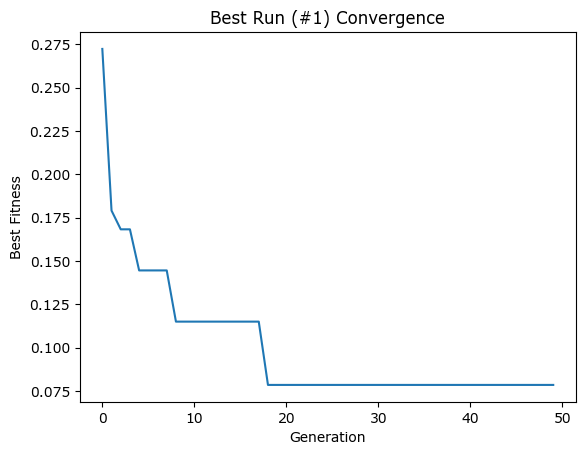

Best angles (rad): [ 0.         -0.26179939 -0.26179939 -0.26179939  0.          0.26179939
  0.26179939  0.26179939  0.         -0.26179939 -0.26179939 -0.26179939
  0.          0.26179939  0.26179939  0.26179939]
Best fitness: 7.847770e-02


In [ ]:
# GA parameters
pop_size   = 100
num_gens   = 50
mut_rate   = 0.3

# Penalty multiplier for By and Bz
alpha      = 1e8

# Number of restarts
n_restarts = 1


# Preallocate storage
d = positions_cpu.shape[0]   # number of magnets
best_angles     = np.zeros((n_restarts, d))
best_fitness    = np.zeros(n_restarts)
Bx_best         = np.zeros(n_restarts)
By_best         = np.zeros(n_restarts)
Bz_best         = np.zeros(n_restarts)
fitness_history = np.zeros((n_restarts, num_gens))


for run in range(n_restarts):

    (best_angles[run],
        best_fitness[run],
        _,
        _,
        _,
        fitness_history[run]
    ) = genetic_algorithm_gpu(
        positions_cpu, 
        init_orientations_gpu,
        l_values, m_values,
        sh_coeff_X, sh_coeff_Y, sh_coeff_Z, points_of_interest,
        possible_angles_cpu,
        population_size=pop_size,
        generations=num_gens,
        mutation_rate=mut_rate,
        objective='homogeneity', # homogeneity or maxBx
        alpha=alpha
    )
    print(f"Run {run+1}/{n_restarts} done, best fitness = {best_fitness[run]:.3e}")
    print(f"Best angles (rad): {best_angles[run]}")

best_run = np.argmin(best_fitness) # min fitness wins
# best_run = np.argmax(best_fitness) # max fitness wins


# Plot the results
plt.plot(fitness_history[best_run])
plt.xlabel("Generation")
plt.ylabel("Best Fitness")
plt.title(f"Best Run (#{best_run+1}) Convergence")
plt.show()

# Print the best angles and best fitness values
print("Best angles (rad):", best_angles[best_run])
print(f"Best fitness: {best_fitness[best_run]:.6e}")